## 8. Khám Phá Dữ Liệu Chuyên Sâu (Deep EDA)

Phân tích trên tập dữ liệu đã lọc (liên tục, không còn đứt gãy lớn) nhằm:
- Quan sát xu hướng và chu kỳ theo thời gian (giờ / tháng)
- Đánh giá tương quan giữa PM2.5 và các biến khí tượng
- Cung cấp cơ sở khoa học cho việc chọn features (ACF/PACF justify lag selection)


════════════════════════════════════════════════════════════
TỔNG QUAN DỮ LIỆU EDA
════════════════════════════════════════════════════════════
Thời gian: 2025-06-23 22:00:00 → 2026-05-10 10:00:00
Tổng số giờ: 7,656
Tỷ lệ PM2.5 hợp lệ: 100.00%
Trung bình PM2.5: 33.24 µg/m³
Max PM2.5: 171.0 | Min: 1.5


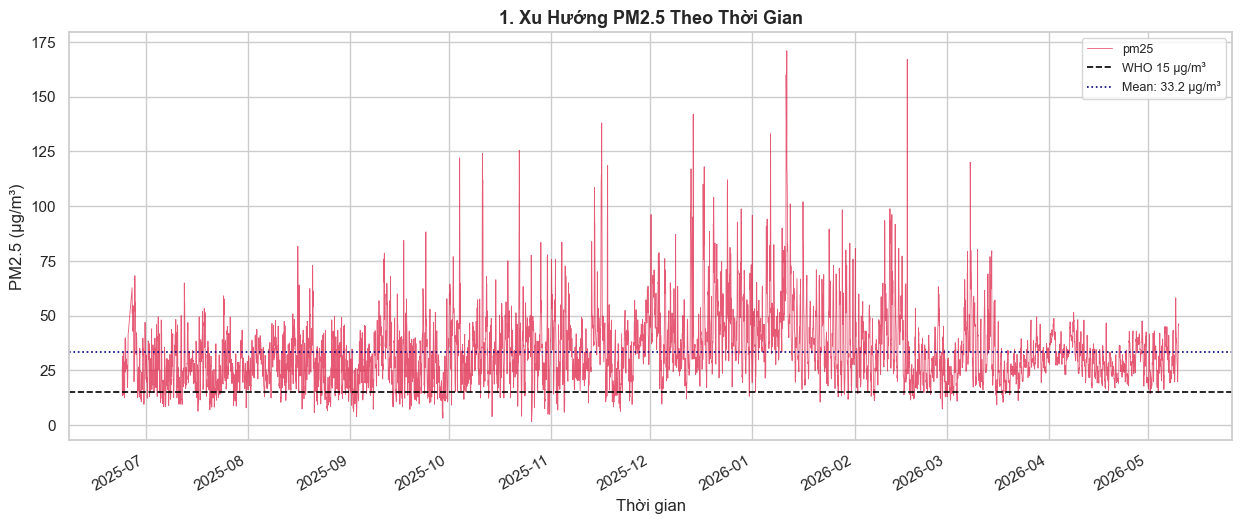

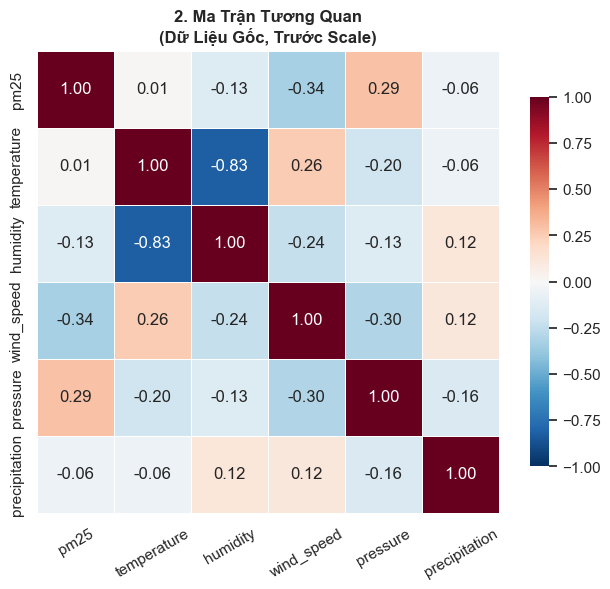

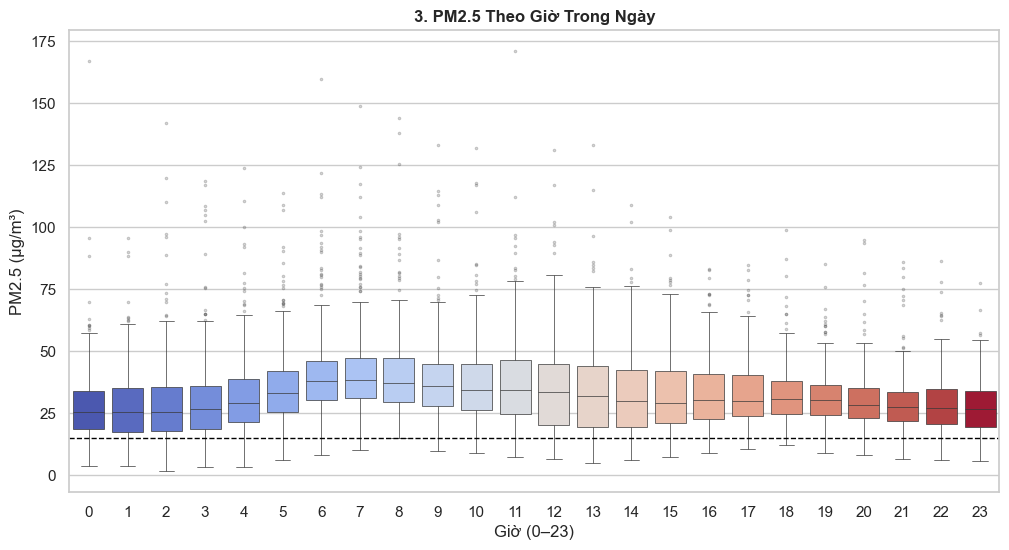

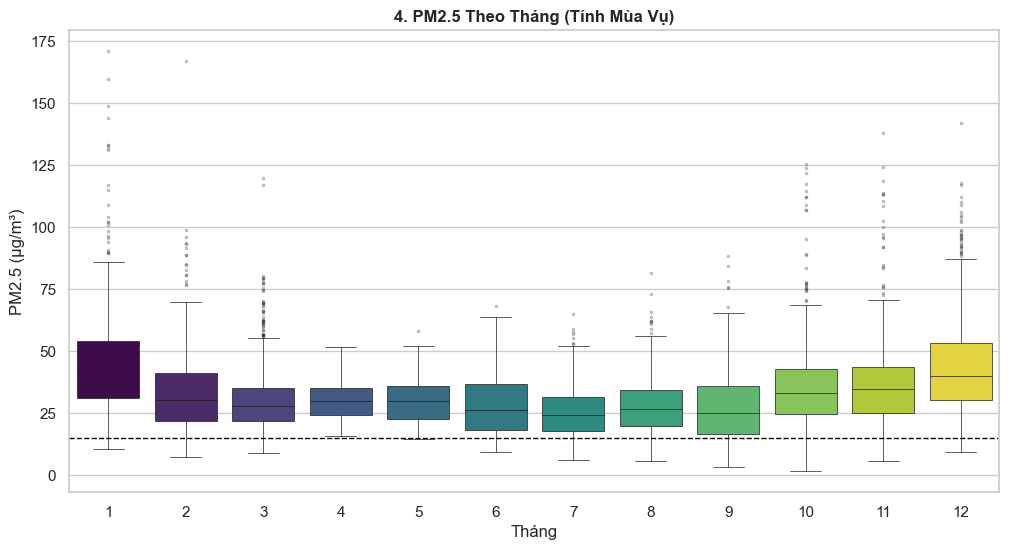

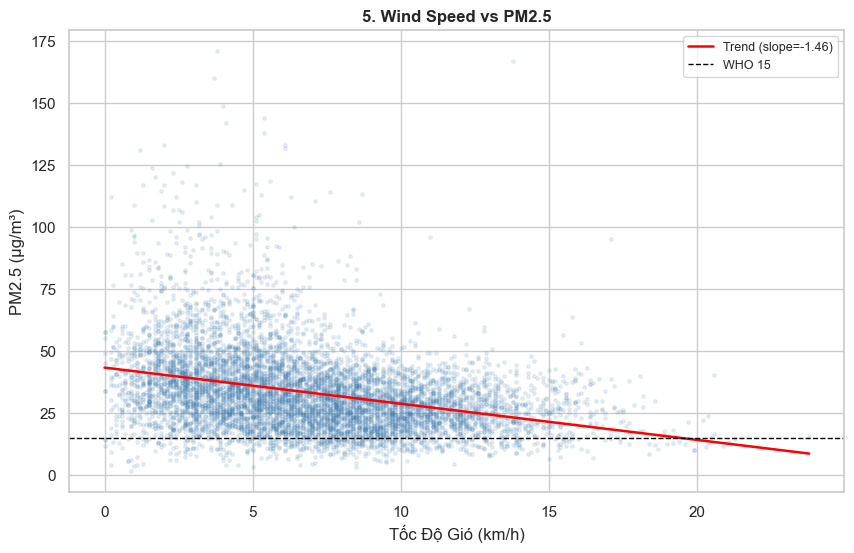


THỐNG KÊ MÔ TẢ PM2.5:
count    7656.00
mean       33.24
std        16.18
min         1.55
25%        22.50
50%        30.60
75%        40.30
max       171.00
Name: pm25, dtype: float64

Tỷ lệ vượt WHO 15 µg/m³ : 92.6%
Tỷ lệ vượt WHO 25 µg/m³ : 67.2%


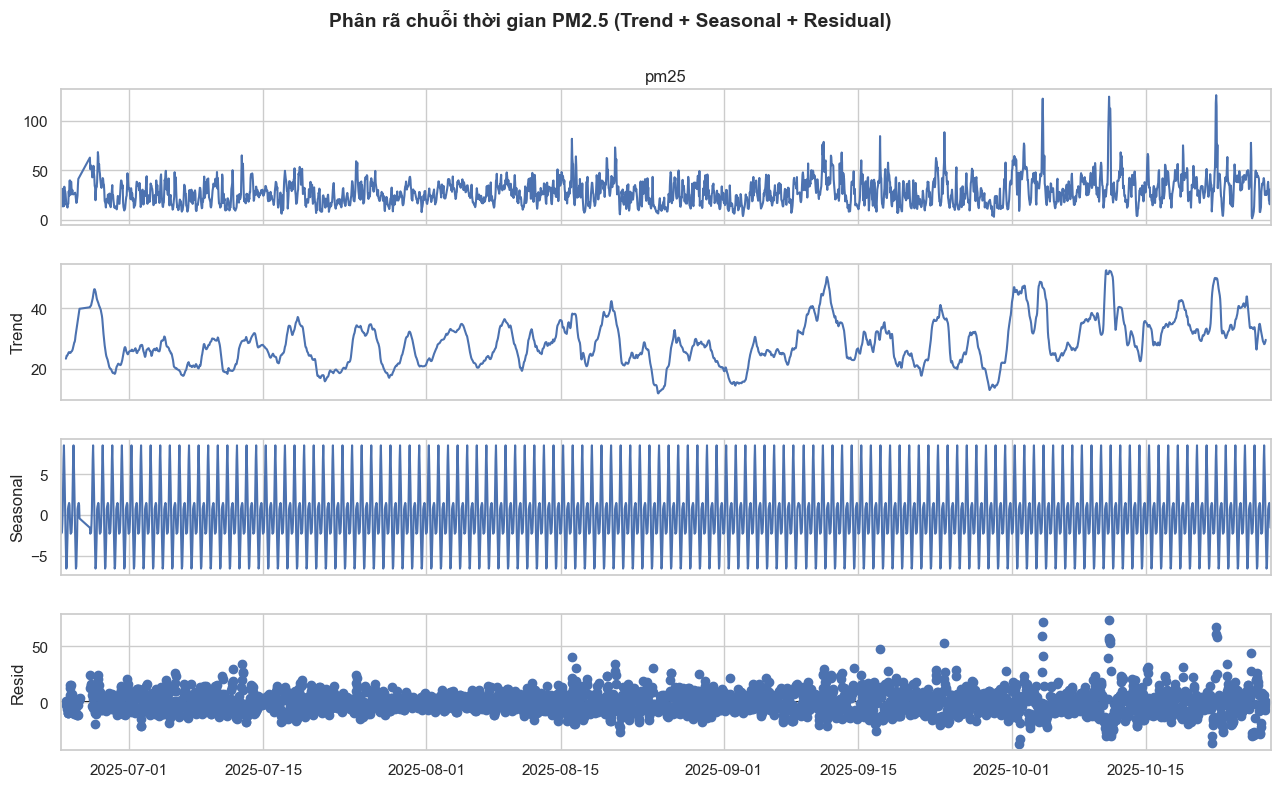

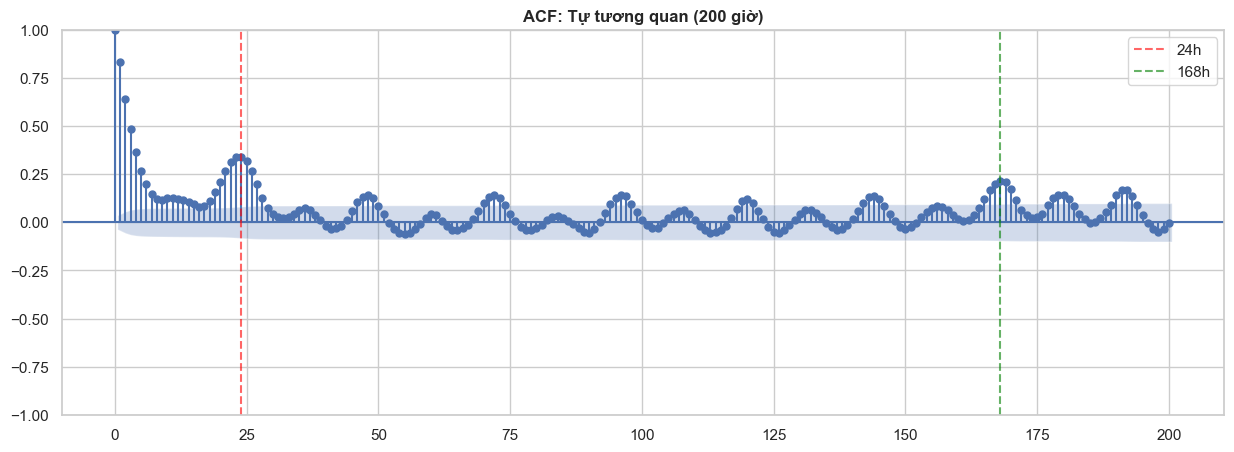

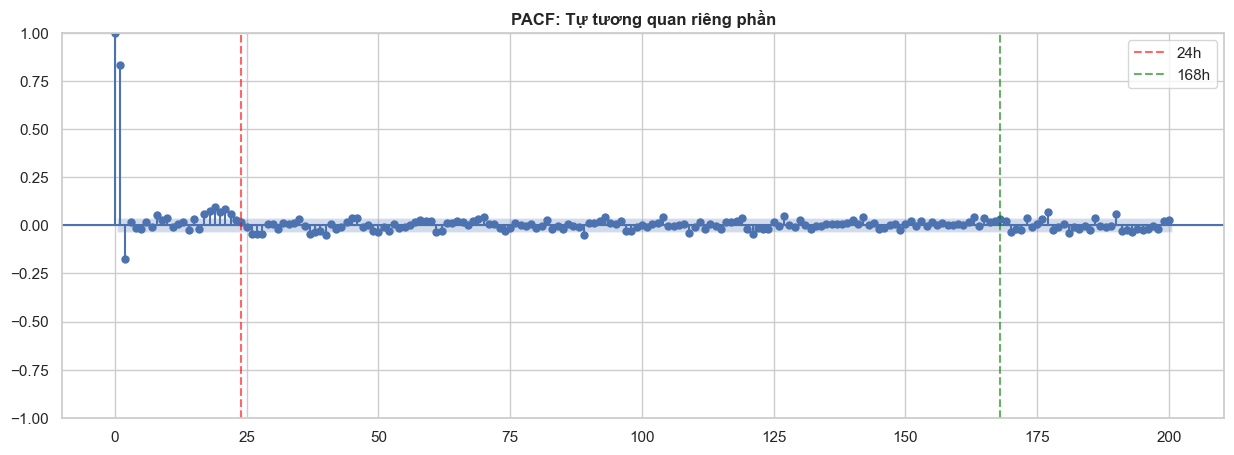

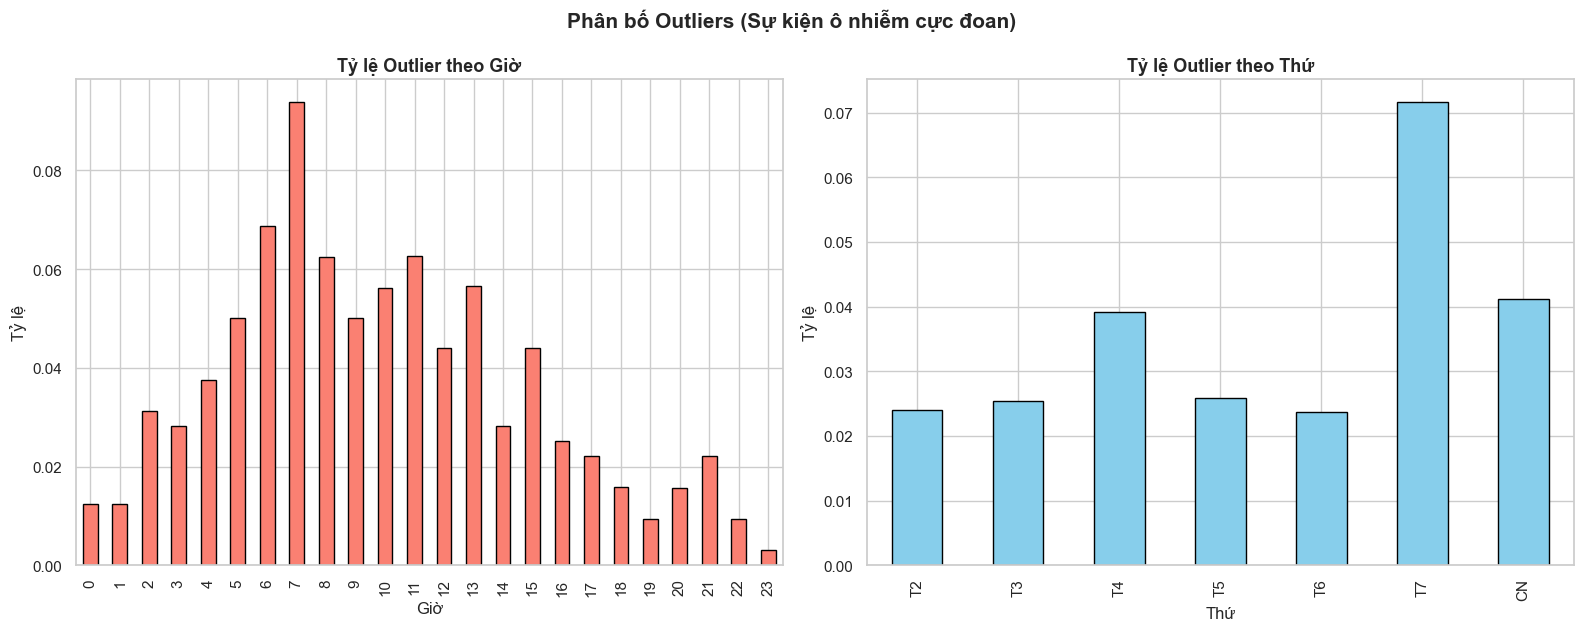

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import joblib
import missingno as msno

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display, Markdown

# Tắt cảnh báo để output sạch hơn
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# 6.1 TỔNG QUAN DỮ LIỆU
# ══════════════════════════════════════════════════════════════════
eda_df = pd.read_csv('../data/processed/cleaned_final.csv')
eda_df['time'] = pd.to_datetime(eda_df['time'])
eda_df = eda_df.set_index('time').sort_index()

print("═" * 60)
print("TỔNG QUAN DỮ LIỆU EDA")
print("═" * 60)
print(f"Thời gian: {eda_df.index.min()} → {eda_df.index.max()}")
print(f"Tổng số giờ: {len(eda_df):,}")
print(f"Tỷ lệ PM2.5 hợp lệ: {eda_df['pm25'].notna().mean()*100:.2f}%")
print(f"Trung bình PM2.5: {eda_df['pm25'].mean():.2f} µg/m³")
print(f"Max PM2.5: {eda_df['pm25'].max():.1f} | Min: {eda_df['pm25'].min():.1f}")

# ══════════════════════════════════════════════════════════════════
# 6.1  DASHBOARD TỔNG QUAN (TÁCH RIÊNG)
# ══════════════════════════════════════════════════════════════════
sns.set_theme(style="whitegrid")

# Hình 1: Time series
plt.figure(figsize=(15, 6))
eda_df['pm25'].plot(color='crimson', alpha=0.7, linewidth=0.6)
plt.axhline(15, color='black', linestyle='--', linewidth=1.2, label='WHO 15 µg/m³')
plt.axhline(eda_df['pm25'].mean(), color='navy', linestyle=':', linewidth=1.2,
            label=f"Mean: {eda_df['pm25'].mean():.1f} µg/m³")
plt.title('1. Xu Hướng PM2.5 Theo Thời Gian', fontsize=13, fontweight='bold')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Thời gian')
plt.legend(fontsize=9)
plt.show()

# Hình 2: Correlation heatmap
plt.figure(figsize=(8, 6))
cols_corr = ['pm25','temperature','humidity','wind_speed','pressure','precipitation']
corr = eda_df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('2. Ma Trận Tương Quan\n(Dữ Liệu Gốc, Trước Scale)', fontsize=12, fontweight='bold')
plt.xticks(rotation=30)
plt.show()

# Hình 3: PM2.5 by hour
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df, x='hour', y='pm25', hue='hour', palette='coolwarm',
            legend=False, linewidth=0.5,
            flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
plt.axhline(15, color='black', linestyle='--', linewidth=1)
plt.title('3. PM2.5 Theo Giờ Trong Ngày', fontsize=12, fontweight='bold')
plt.xlabel('Giờ (0–23)')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

# Hình 4: PM2.5 by month
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df, x='month', y='pm25', hue='month', palette='viridis',
            legend=False, linewidth=0.5,
            flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
plt.axhline(15, color='black', linestyle='--', linewidth=1)
plt.title('4. PM2.5 Theo Tháng (Tính Mùa Vụ)', fontsize=12, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

# Hình 5: Wind vs PM2.5
plt.figure(figsize=(10, 6))
tmp = eda_df[['wind_speed','pm25']].dropna()
plt.scatter(tmp['wind_speed'], tmp['pm25'], alpha=0.12, s=6, color='steelblue')
z    = np.polyfit(tmp['wind_speed'], tmp['pm25'], 1)
x_ln = np.linspace(tmp['wind_speed'].min(), tmp['wind_speed'].max(), 100)
plt.plot(x_ln, np.poly1d(z)(x_ln), color='red', linewidth=1.8, label=f'Trend (slope={z[0]:.2f})')
plt.axhline(15, color='black', linestyle='--', linewidth=1, label='WHO 15')
plt.title('5. Wind Speed vs PM2.5', fontsize=12, fontweight='bold')
plt.xlabel('Tốc Độ Gió (km/h)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend(fontsize=9)
plt.show()

print("\nTHỐNG KÊ MÔ TẢ PM2.5:")
print(eda_df['pm25'].describe().round(2))
print(f"\nTỷ lệ vượt WHO 15 µg/m³ : {(eda_df['pm25'] > 15).mean()*100:.1f}%")
print(f"Tỷ lệ vượt WHO 25 µg/m³ : {(eda_df['pm25'] > 25).mean()*100:.1f}%")

# ══════════════════════════════════════════════════════════════════
# 6.2  SEASONAL DECOMPOSITION
# ══════════════════════════════════════════════════════════════════
pm25_series = eda_df['pm25'].dropna().iloc[:3000]
decomposition = seasonal_decompose(pm25_series, model='additive', period=24)
fig_dec = decomposition.plot()
fig_dec.set_size_inches(14, 8)
plt.suptitle('Phân rã chuỗi thời gian PM2.5 (Trend + Seasonal + Residual)',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# ════════════════════════════════════════════════════════════════════
# 6.3  ACF / PACF
# ════════════════════════════════════════════════════════════════════
plt.figure(figsize=(15, 5))
plot_acf(pm25_series, lags=200, ax=plt.gca(), alpha=0.05)
plt.title('ACF: Tự tương quan (200 giờ)', fontweight='bold')
plt.axvline(x=24,  color='red',   linestyle='--', alpha=0.6, label='24h')
plt.axvline(x=168, color='green', linestyle='--', alpha=0.6, label='168h')
plt.legend()
plt.show()

plt.figure(figsize=(15, 5))
plot_pacf(pm25_series, lags=200, ax=plt.gca(), alpha=0.05, method='ywm')
plt.title('PACF: Tự tương quan riêng phần', fontweight='bold')
plt.axvline(x=24,  color='red',   linestyle='--', alpha=0.6, label='24h')
plt.axvline(x=168, color='green', linestyle='--', alpha=0.6, label='168h')
plt.legend()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 6.4  OUTLIER DISTRIBUTION (GỘP CHUNG)
# ══════════════════════════════════════════════════════════════════
Q1  = eda_df['pm25'].quantile(0.25)
Q3  = eda_df['pm25'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (eda_df['pm25'] < (Q1 - 1.5*IQR)) | (eda_df['pm25'] > (Q3 + 1.5*IQR))

# Tạo khung hình với 1 hàng và 2 cột
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tỷ lệ Outlier theo Giờ
outlier_by_hour = eda_df[outlier_mask].groupby('hour').size() / eda_df.groupby('hour').size()
outlier_by_hour.plot(kind='bar', color='salmon', edgecolor='black', ax=axes[0])
axes[0].set_title('Tỷ lệ Outlier theo Giờ', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Tỷ lệ')
axes[0].set_xlabel('Giờ')

# Biểu đồ 2: Tỷ lệ Outlier theo Thứ
outlier_by_dow = eda_df[outlier_mask].groupby('dayofweek').size() / eda_df.groupby('dayofweek').size()
dow_names = ['T2','T3','T4','T5','T6','T7','CN']
outlier_by_dow.index = [dow_names[i] for i in outlier_by_dow.index]
outlier_by_dow.plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Tỷ lệ Outlier theo Thứ', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Tỷ lệ')
axes[1].set_xlabel('Thứ')

plt.tight_layout() # Tự động căn chỉnh để không bị đè chữ
plt.suptitle('Phân bố Outliers (Sự kiện ô nhiễm cực đoan)', fontsize=15, fontweight='bold', y=1.05)
plt.show()